---

# **Práctica I**: Resolver un sudoku contenido en una imagen digital



---
## **Enunciado**

Reconocimiento de la información de un sudoku a partir de la imagen "sudoku.jpg" en la que aparece el estado inicial del sudoku que se quiere resolver

**Se pide**: un programa en python que dada una imagen en la que aparezca un sudoku (puede ser sudoku.jpg o cualquier otra) nos devuelva una matriz de 9x9 con la información que hay en cada una de las casillas (de 1 a 9 si hay dígito y 0 si no hay nada)

**Nota**: dada la imagen sudoku.jpg el resultado sería:

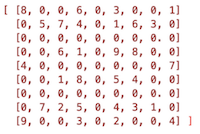

**Optativo**: quien quiera profundizar en el desarrollo de esta práctica, puede continuar el desarrollo de la misma implementando un programa en Python que dada una imagen capturada con el móvil devuelva el resultado del sudoku (utilizando el método por backtrakking que se incluye en este cuaderno o cualquier otro que se eliga para su resolución)

**Nota**: para el reconocimiento de los dígitos presentes en el sudoku se puede emplear cualquier biblioteca de funciones en python que posibilite manejar un OCR

**Normas**: La práctica se puede entregar:

  (a) en un cuaderno en Python para Colab (extensión .ypynb) incluyendo una breve memor ia explicativa en el mismo cuaderno

  (b) en un fichero de código en Python (extensión .py) adjuntando un breve memoria explicativa en otro fichero en formato pdf


---

## Comentarios y ayudas


---
###**Resolución de sudokus por backtrakking**:

---

In [ ]:
# soluciones de sudokus por backtrakking

def solve_sudoku(board):
    empty = find_empty(board)
    if not empty:
        return True  # No quedan casillas vacías, el sudoku está resuelto.

    row, col = empty

    for num in range(1, 10):
        if is_valid(board, num, (row, col)):
            board[row][col] = num

            if solve_sudoku(board):
                return True

            board[row][col] = 0  # Si no se encuentra una solución, restablecer la casilla.

    return False

def find_empty(board):
    for i in range(len(board)):
        for j in range(len(board[i])):
            if board[i][j] == 0:
                return (i, j)
    return None

def is_valid(board, num, pos):
    # Verificar la fila
    for i in range(len(board[0])):
        if board[pos[0]][i] == num and pos[1] != i:
            return False

    # Verificar la columna
    for i in range(len(board)):
        if board[i][pos[1]] == num and pos[0] != i:
            return False

    # Verificar el cuadro de 3x3
    box_x = pos[1] // 3
    box_y = pos[0] // 3
    for i in range(box_y * 3, box_y * 3 + 3):
        for j in range(box_x * 3, box_x * 3 + 3):
            if board[i][j] == num and (i, j) != pos:
                return False

    return True

def print_board(board):
    for i in range(len(board)):
        if i % 3 == 0 and i != 0:
            print("- - - - - - - - - - - -")
        for j in range(len(board[i])):
            if j % 3 == 0 and j != 0:
                print(" | ", end="")
            if j == 8:
                print(board[i][j])
            else:
                print(str(board[i][j]) + " ", end="")

# Ejemplo de uso:
sudoku_board = [
    [8, 0, 0, 6, 0, 3, 0, 0, 1],
    [0, 5, 7, 4, 0, 1, 6, 3, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 6, 1, 0, 9, 8, 0, 0],
    [4, 0, 0, 0, 0, 0, 0, 0, 7],
    [0, 0, 1, 8, 0, 5, 4, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 7, 2, 5, 0, 4, 3, 1, 0],
    [9, 0, 0, 3, 0, 2, 0, 0, 4]
]

print("Tablero Original:")
print_board(sudoku_board)
solve_sudoku(sudoku_board)
print("\nTablero Resuelto:")
print_board(sudoku_board)
